**Objective 2**

Dataset Preparation & Visualisation (OpenCV / NumPy)

This notebook focuses on loading and inspecting the dataset using OpenCV and NumPy, providing a lower-level look at the data before model training.

Step 1: Import Libraries

In [ ]:
import os
import glob
import random
import cv2
import numpy as np
from matplotlib import pyplot as plt

print('Libraries imported successfully!')

Step 2: Capture Training Image Info as a List

In [ ]:
# ── Update these paths to point to your data ─────────────────────────
image_directory = 'data/images'
mask_directory  = 'data/masks'

train_images = []

for directory_path in glob.glob(image_directory):
    for img_path in glob.glob(os.path.join(directory_path, '*.JPG')):
        print(img_path)
        img = cv2.imread(img_path, 1)
        train_images.append(img)

print(f'\nTotal images loaded: {len(train_images)}')

Step 3: Convert Image List to NumPy Array

In [ ]:
train_images = np.array(train_images)
print('train_images.shape:', train_images.shape)
# Expected: (200, 250, 250, 3)

Step 4: Capture Mask / Label Info as a List

In [ ]:
train_masks = []

for directory_path in glob.glob(mask_directory):
    for mask_path in glob.glob(os.path.join(directory_path, '*.PNG')):
        print(mask_path)
        mask = cv2.imread(mask_path, 0)   # grayscale
        train_masks.append(mask)

print(f'\nTotal masks loaded: {len(train_masks)}')

Step 5: Convert Mask List to NumPy Array

In [ ]:
train_masks = np.array(train_masks)
print('train_masks.shape:', train_masks.shape)
# Expected: (200, 250, 250)

Step 6: Display a Random Image–Mask Pair

In [ ]:
img_number = random.randint(0, len(train_images) - 1)
img  = train_images[img_number]
mask = train_masks[img_number]

plt.figure(figsize=(12, 8))
plt.subplot(121); plt.title('Image'); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(122); plt.title('Mask');  plt.imshow(mask, cmap='gray')
plt.tight_layout()
plt.show()

Steps 7–10: Load via File Paths (Alternative Method)

In [ ]:
# Collect and sort file paths
image_names = glob.glob(os.path.join(image_directory, '*.JPG'))
image_names.sort()
print('First 3 image paths:')
print(*image_names[:3], sep='\n')

mask_names = glob.glob(os.path.join(mask_directory, '*.PNG'))
mask_names.sort()
print('\nFirst 3 mask paths:')
print(*mask_names[:3], sep='\n')

In [ ]:
images       = [cv2.imread(image, 1) for image in image_names]
image_dataset = np.array(images)
print('image_dataset.shape:', image_dataset.shape)

masks        = [cv2.imread(mask, 0)  for mask  in mask_names]
mask_dataset  = np.array(masks)
print('mask_dataset.shape: ', mask_dataset.shape)

Step 11: Display Another Random Pair (from path-loaded arrays)

In [ ]:
img_number = random.randint(0, len(train_images) - 1)
img  = image_dataset[img_number]
mask = mask_dataset[img_number]

plt.figure(figsize=(12, 8))
plt.subplot(121); plt.title('Image'); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(122); plt.title('Mask');  plt.imshow(mask, cmap='viridis')
plt.tight_layout()
plt.show()

**SUMMARY**

**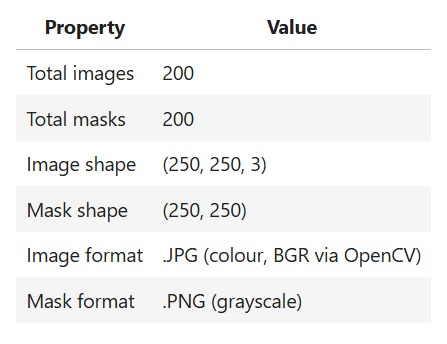**
